# Oil Slick Detection — Baseline CNN Pipeline
**Seminar: Deep Learning for Maritime Vision Applications**

This notebook:
1. Downloads the WaterBench OilSlick S1 dataset
2. Explores the data (visualisations, class balance, metadata)
3. Trains a ResNet-18 baseline (2-channel VV/VH input)
4. Evaluates on random & geographic (Mediterranean OOD) splits
5. Shows confusion matrices and sample predictions

## 0 — Install Dependencies

In [1]:
# !pip install -q huggingface_hub rasterio tifffile scikit-learn matplotlib seaborn

In [2]:
# Running on server — no Colab drive mount needed
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
# Cell 2 — Point to data on server
import os

BASE_DIR  = "/mnt/data/home/sf2522/oilslick-detection"
OILSLICK  = os.path.join(BASE_DIR, "data", "data", "OilSlick")  # metadata + splits live here
img_dir   = os.path.join(OILSLICK, "images_s1")

# Sanity check
tif_count = len([f for f in os.listdir(img_dir) if f.endswith(".tif")])
print(f"img_dir  : {img_dir}")
print(f"TIF files: {tif_count}  (expected 1363)")
print(f"metadata : {os.path.exists(os.path.join(OILSLICK, 'metadata.csv'))}")
print(f"splits   : {os.path.exists(os.path.join(OILSLICK, 'splits'))}")

img_dir  : /mnt/data/home/sf2522/oilslick-detection/data/data/OilSlick/images_s1
TIF files: 981  (expected 1363)
metadata : True
splits   : True


## 2 — Data Exploration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

sns.set_style("whitegrid")

# ── 2.1  Load metadata ──────────────────────────────────────────────────────
meta = pd.read_csv(os.path.join(OILSLICK, "metadata.csv"))
print(f"Metadata shape: {meta.shape}")
print(f"\nColumns:\n{list(meta.columns)}")
meta.head()

Metadata shape: (1363, 24)

Columns:
['sample_id', 'label', 'subcategory', 'source_date', 'center_lon', 'center_lat', 'date_diff_days', 'nodata_fraction', 'is_valid', 'image_path', 'rgb_path', 'swir_path', 'n_bands', 'band_order', 'scene_id', 'scene_datetime', 'platform', 'cloud_cover', 'sun_azimuth', 'sun_elevation', 'proj_epsg', 'reflectance_min', 'reflectance_max', 'reflectance_mean']


,sample_id,label,subcategory,source_date,center_lon,center_lat,date_diff_days,nodata_fraction,is_valid,image_path,...,scene_id,scene_datetime,platform,cloud_cover,sun_azimuth,sun_elevation,proj_epsg,reflectance_min,reflectance_max,reflectance_mean
0,pos_00001,1,Ships,20170626,34.8720,25.6463,1,0.0,True,images/positive/pos_00001.tif,...,S2A_MSIL2A_20170627T081001_R078_T36RXP_2021021...,2017-06-27T08:10:01.026000+00:00,Sentinel-2A,0.078479,-1,-1,NaN,0.0288,0.1538,0.049075
1,pos_00007,1,Ships,20170501,14.8150,35.8750,-1,0.0,True,images/positive/pos_00007.tif,...,S2B_MSIL2A_20170430T094029_R036_T33SVV_2021020...,2017-04-30T09:40:29.027000+00:00,Sentinel-2B,21.981618,-1,-1,NaN,0.0001,0.3322,0.022737
2,pos_00013,1,Platforms,20160526,0.9269,57.7068,1,0.0,True,images/positive/pos_00013.tif,...,S2A_MSIL2A_20160527T110702_R137_T31VCE_2021021...,2016-05-27T11:07:02.027000+00:00,Sentinel-2A,0.857883,-1,-1,NaN,0.0001,1.0000,0.010534
3,pos_00017,1,Ships,20190726,128.3855,-14.3665,1,0.0,True,images/positive/pos_00017.tif,...,S2A_MSIL2A_20190727T014701_R074_T52LDK_2020110...,2019-07-27T01:47:01.024000+00:00,Sentinel-2A,18.741675,-1,-1,NaN,0.0001,0.1638,0.015806
4,pos_00022,1,Ships,20180319,104.8076,1.5932,0,0.0,True,images/positive/pos_00022.tif,...,S2B_MSIL2A_20180319T030539_R075_T48NVG_2020101...,2018-03-19T03:05:39.027000+00:00,Sentinel-2B,25.441538,-1,-1,NaN,0.0051,1.0000,0.045527


In [5]:
# Load full metadata for label lookup (before any filtering)
meta_full = pd.read_csv(os.path.join(OILSLICK, "metadata.csv"))
full_label_map = dict(zip(meta_full["sample_id"], meta_full["label"]))
print(f"Full label map: {len(full_label_map)} entries")

Full label map: 1363 entries


In [6]:
# Keep only pos and neg, exclude ext_pos and ext_neg
meta = meta[~meta["sample_id"].str.startswith("ext")].reset_index(drop=True)

print(f"Filtered metadata: {len(meta)} rows")
print(meta["label"].value_counts())

Filtered metadata: 1000 rows
label
1    500
0    500
Name: count, dtype: int64


In [7]:
# img_dir and OILSLICK are defined in Cell 2

# Build set of sample IDs that actually exist on disk
available_ids = set(
    f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
)

# Filter meta to only those IDs
meta = meta[meta["sample_id"].isin(available_ids)].reset_index(drop=True)

print(f"Available on disk : {len(available_ids)}")
print(f"Metadata rows kept: {len(meta)}")
print(meta["label"].value_counts())

Available on disk : 981
Metadata rows kept: 970
label
1    486
0    484
Name: count, dtype: int64


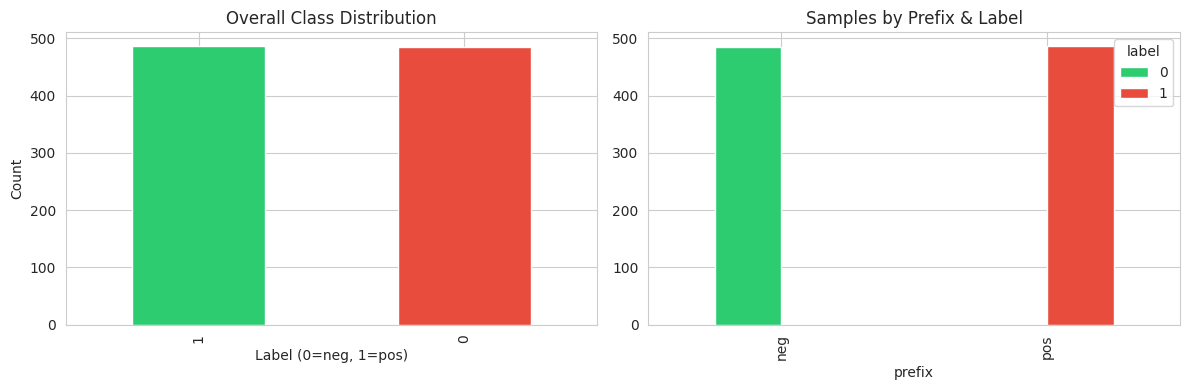

In [8]:
# ── 2.2  Class distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall
meta["label"].value_counts().plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Overall Class Distribution")
axes[0].set_xlabel("Label (0=neg, 1=pos)")
axes[0].set_ylabel("Count")

# By prefix
meta["prefix"] = meta["sample_id"].str.extract(r"^(pos|neg|ext_pos|ext_neg)")
meta.groupby(["prefix", "label"]).size().unstack(fill_value=0).plot.bar(
    ax=axes[1], color=["#2ecc71", "#e74c3c"]
)
axes[1].set_title("Samples by Prefix & Label")
plt.tight_layout()
plt.show()

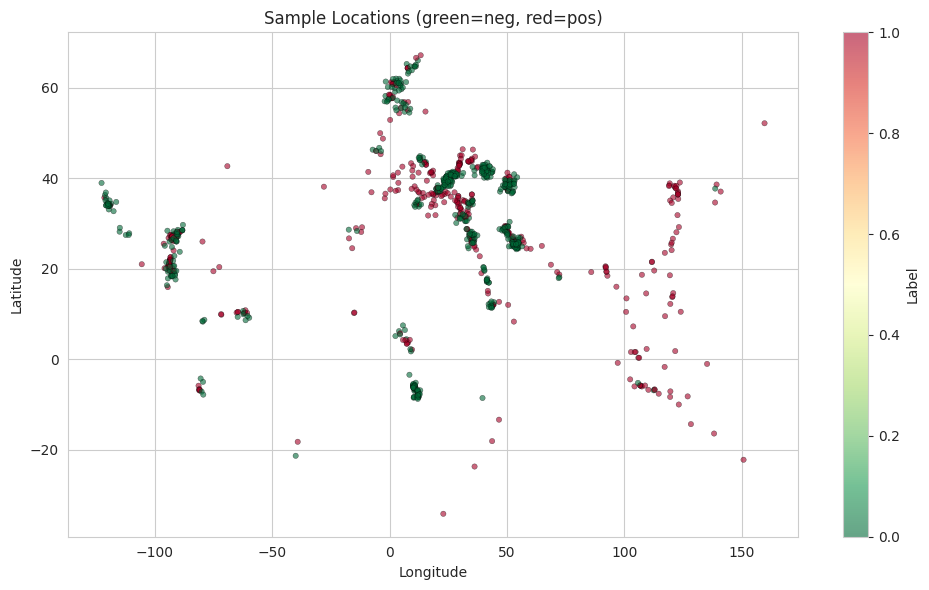

In [9]:
# ── 2.3  Geographic distribution ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    meta["center_lon"], meta["center_lat"],
    c=meta["label"], cmap="RdYlGn_r", alpha=0.6, s=15,
    edgecolors="k", linewidths=0.3,
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Sample Locations (green=neg, red=pos)")
plt.colorbar(scatter, ax=ax, label="Label")
plt.tight_layout()
plt.show()

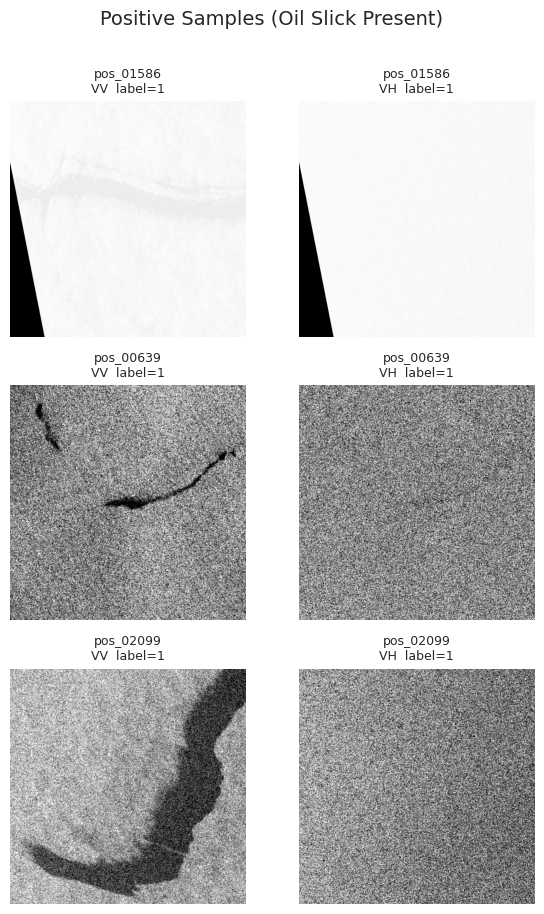

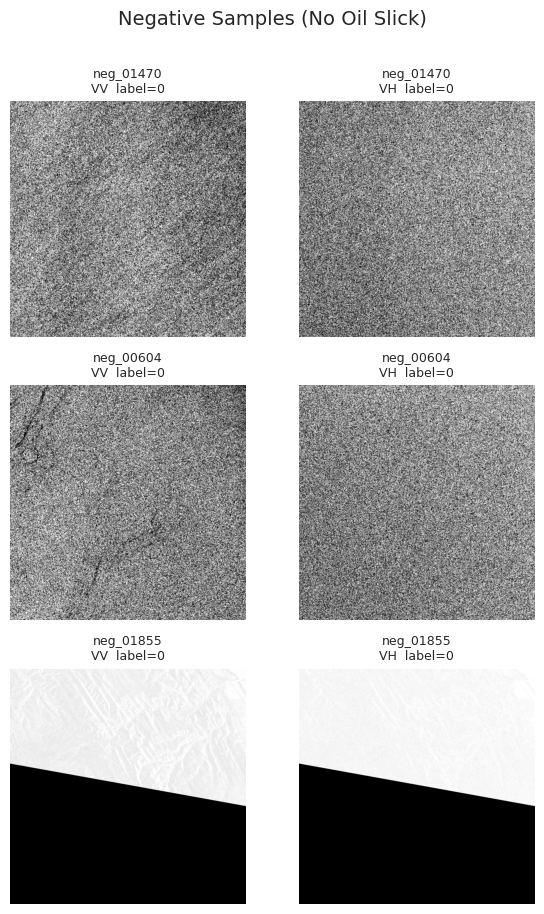

In [10]:
# ── 2.4  Visualise sample chips ─────────────────────────────────────────────

def load_chip(sample_id):
    """Load a 2-band S1 chip as numpy array (2, 224, 224)."""
    path = os.path.join(img_dir, f"{sample_id}_s1.tif")
    with rasterio.open(path) as src:
        data = src.read()  # shape: (2, H, W)
    return data


def show_chips(sample_ids, labels, title=""):
    """Show VV and VH bands side by side for a list of samples."""
    n = len(sample_ids)
    fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=14, y=1.01)
    for i, (sid, lab) in enumerate(zip(sample_ids, labels)):
        chip = load_chip(sid)
        for j, band_name in enumerate(["VV", "VH"]):
            ax = axes[i, j]
            band = chip[j]
            vmin, vmax = np.percentile(band[band != 0], [2, 98])
            ax.imshow(band, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(f"{sid}\n{band_name}  label={lab}", fontsize=9)
            ax.axis("off")
    plt.tight_layout()
    plt.show()


# Show 3 positive + 3 negative examples
pos_ids = meta[meta["label"] == 1]["sample_id"].sample(3, random_state=41).tolist()
neg_ids = meta[meta["label"] == 0]["sample_id"].sample(3, random_state=41).tolist()

show_chips(pos_ids, [1] * 3, title="Positive Samples (Oil Slick Present)")
show_chips(neg_ids, [0] * 3, title="Negative Samples (No Oil Slick)")

In [11]:
import os

files = os.listdir(img_dir)
tif_files = [f for f in files if f.endswith(".tif")]

# Count by prefix
from collections import Counter
prefixes = Counter(f.split("_")[0] + "_" + f.split("_")[1]
                   if f.startswith("ext") else f.split("_")[0]
                   for f in tif_files)
print("Files on Drive by prefix:")
for prefix, count in sorted(prefixes.items()):
    print(f"  {prefix}: {count}")
print(f"  TOTAL: {len(tif_files)}")

Files on Drive by prefix:
  ext_pos: 11
  neg: 484
  pos: 486
  TOTAL: 981


## Per-Channel Statistics

The raw pixel values from the SAR GeoTIFF are in **decibel (dB) scale**,
typically ranging from -30 to 0 dB for open ocean scenes.

Key observations from our data:
- **Mean VV: -28.8, Mean VH: -36.8** — typical open ocean backscatter
- **Std VV: 42.6, Std VH: 39.1** — unusually high, driven by outliers
- **Min: -163** — nodata sentinel value, must be masked
- **Max: ~1997** — extreme outliers from ships or coastlines

Since these outliers would dominate z-score normalisation and squash the
meaningful ocean signal, we clip values to the range [-50, 10] dB before
normalising.

Computing per-channel statistics on a sample of chips...


VV — mean: -28.8261, std: 42.6084, min: -163.0000, max: 1997.7247
VH — mean: -36.8668, std: 39.1635, min: -163.0000, max: 985.9646


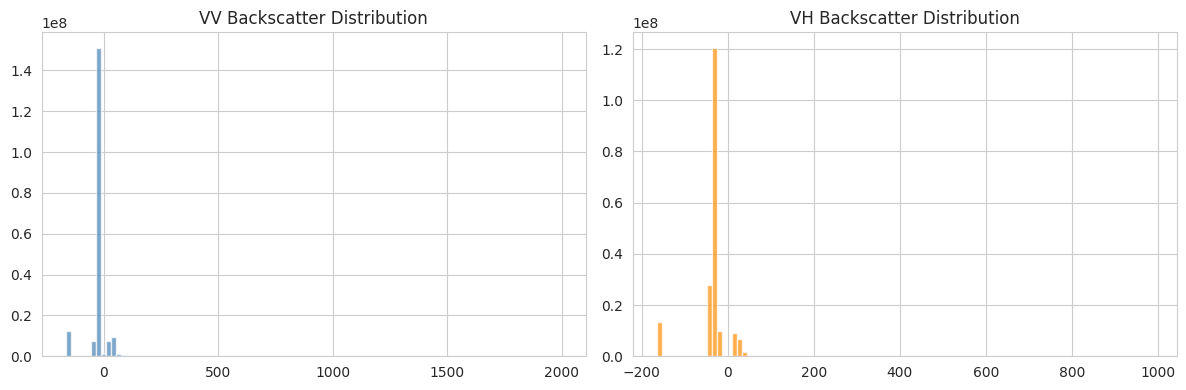

In [12]:
# ── 2.5  Per-channel statistics ──────────────────────────────────────────────
print("Computing per-channel statistics on a sample of chips...")
rng = np.random.RandomState(0)
sample_ids_all = meta["sample_id"].values
subset = rng.choice(sample_ids_all, size=min(200, len(sample_ids_all)), replace=False)

all_vv, all_vh = [], []
for sid in subset:
    chip = load_chip(sid)
    valid = chip != 0  # mask nodata
    all_vv.append(chip[0][valid[0]])
    all_vh.append(chip[1][valid[1]])

all_vv = np.concatenate(all_vv)
all_vh = np.concatenate(all_vh)

print(f"VV — mean: {all_vv.mean():.4f}, std: {all_vv.std():.4f}, "
      f"min: {all_vv.min():.4f}, max: {all_vv.max():.4f}")
print(f"VH — mean: {all_vh.mean():.4f}, std: {all_vh.std():.4f}, "
      f"min: {all_vh.min():.4f}, max: {all_vh.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(all_vv, bins=100, color="steelblue", alpha=0.7)
axes[0].set_title("VV Backscatter Distribution")
axes[1].hist(all_vh, bins=100, color="darkorange", alpha=0.7)
axes[1].set_title("VH Backscatter Distribution")
plt.tight_layout()
plt.show()

## 3 — Dataset & DataLoader

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader


class OilSlickDataset(Dataset):
    def __init__(self, split_file, img_dir, label_map,
                 vv_mean, vv_std, vh_mean, vh_std, augment=False):

        available = set(
            f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
        )

        with open(split_file) as f:
            all_ids = [line.strip() for line in f if line.strip()]

        # Only keep IDs that exist on disk AND have a label
        self.sample_ids = [sid for sid in all_ids
                           if sid in available and sid in label_map]

        skipped = len(all_ids) - len(self.sample_ids)
        if skipped > 0:
            print(f"  [{split_file.split('/')[-1]}] Skipped {skipped}, "
                  f"using {len(self.sample_ids)}")

        self.img_dir = img_dir
        self.label_map = label_map
        self.vv_mean, self.vv_std = vv_mean, vv_std
        self.vh_mean, self.vh_std = vh_mean, vh_std
        self.augment = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
      sid = self.sample_ids[idx]
      path = os.path.join(self.img_dir, f"{sid}_s1.tif")
      with rasterio.open(path) as src:
          chip = src.read().astype(np.float32)

      # Clean
      chip[chip == -163.0] = 0.0
      chip[0] = np.clip(chip[0], -50, 10)
      chip[1] = np.clip(chip[1], -50, 10)

      # Z-score normalise
      chip[0] = (chip[0] - self.vv_mean) / (self.vv_std + 1e-8)
      chip[1] = (chip[1] - self.vh_mean) / (self.vh_std + 1e-8)

      chip = torch.from_numpy(chip)

      if self.augment:
          # Flips
          if torch.rand(1).item() > 0.5:
              chip = torch.flip(chip, dims=[2])
          if torch.rand(1).item() > 0.5:
              chip = torch.flip(chip, dims=[1])
          # 90° rotations
          k = torch.randint(0, 4, (1,)).item()
          chip = torch.rot90(chip, k, dims=[1, 2])
          # Small Gaussian noise
          chip = chip + 0.05 * torch.randn_like(chip)

      label = torch.tensor(self.label_map[sid], dtype=torch.float32)
      return chip, label

In [15]:
# ── 3.1  Compute normalisation stats on RANDOM training split ───────────────

def compute_channel_stats(split_file, img_dir):
    """Compute per-channel mean and std from training samples."""
    with open(split_file) as f:
        train_ids = [line.strip() for line in f if line.strip()]
    # train_ids = [sid for sid in train_ids if sid in available]

    vv_vals, vh_vals = [], []
    for sid in train_ids:
        path = os.path.join(img_dir, f"{sid}_s1.tif")
        with rasterio.open(path) as src:
            chip = src.read().astype(np.float32)
        mask = chip != 0
        vv_vals.append(chip[0][mask[0]])
        vh_vals.append(chip[1][mask[1]])

    vv_all = np.concatenate(vv_vals)
    vh_all = np.concatenate(vh_vals)
    return vv_all.mean(), vv_all.std(), vh_all.mean(), vh_all.std()


# random_train_file = os.path.join(OILSLICK, "splits", "random", "train.txt")
# vv_mean, vv_std, vh_mean, vh_std = compute_channel_stats(random_train_file, img_dir)
# print(f"Training stats — VV: μ={vv_mean:.4f} σ={vv_std:.4f}  |  "
#       f"VH: μ={vh_mean:.4f} σ={vh_std:.4f}")

In [ ]:
# Check what IDs are in the train split vs what's on disk
random_train_file = os.path.join(OILSLICK, "splits", "random", "train.txt")

with open(random_train_file) as f:
    train_ids = [line.strip() for line in f if line.strip()]

available = set(f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif"))

missing  = [sid for sid in train_ids if sid not in available]
present  = [sid for sid in train_ids if sid in available]

print(f"Total in train.txt : {len(train_ids)}")
print(f"Available on disk  : {len(present)}")
print(f"Missing            : {len(missing)}")
print(f"Sample missing IDs : {missing[:5]}")


In [17]:
def compute_channel_stats(split_file, img_dir):
    """Memory-efficient per-channel mean and std using vectorised Welford's algorithm."""
    available = set(
        f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
    )

    with open(split_file) as f:
        train_ids = [line.strip() for line in f if line.strip()]
    train_ids = [sid for sid in train_ids if sid in available]
    print(f"Computing stats over {len(train_ids)} training chips...")

    vv_count = vv_mean = vv_M2 = 0.0
    vh_count = vh_mean = vh_M2 = 0.0

    for i, sid in enumerate(train_ids):
        path = os.path.join(img_dir, f"{sid}_s1.tif")
        with rasterio.open(path) as src:
            chip = src.read().astype(np.float32)

        # Clean
        chip[chip == -163.0] = np.nan
        chip[0] = np.clip(chip[0], -50, 10)
        chip[1] = np.clip(chip[1], -50, 10)

        # VV — vectorised Welford merge
        vv_pixels = chip[0][~np.isnan(chip[0])].ravel()
        n = len(vv_pixels)
        if n > 0:
            batch_mean = vv_pixels.mean()
            batch_var  = vv_pixels.var()
            delta      = batch_mean - vv_mean
            vv_mean    = (vv_mean * vv_count + batch_mean * n) / (vv_count + n)
            vv_M2     += batch_var * n + delta**2 * vv_count * n / (vv_count + n)
            vv_count  += n

        # VH — vectorised Welford merge
        vh_pixels = chip[1][~np.isnan(chip[1])].ravel()
        n = len(vh_pixels)
        if n > 0:
            batch_mean = vh_pixels.mean()
            batch_var  = vh_pixels.var()
            delta      = batch_mean - vh_mean
            vh_mean    = (vh_mean * vh_count + batch_mean * n) / (vh_count + n)
            vh_M2     += batch_var * n + delta**2 * vh_count * n / (vh_count + n)
            vh_count  += n

        if (i + 1) % 100 == 0:
            print(f"  Processed {i+1}/{len(train_ids)} chips...")

    vv_std = np.sqrt(vv_M2 / vv_count)
    vh_std = np.sqrt(vh_M2 / vh_count)

    print(f"Done ✓")
    return float(vv_mean), float(vv_std), float(vh_mean), float(vh_std)


random_train_file = os.path.join(OILSLICK, "splits", "random", "train.txt")
vv_mean, vv_std, vh_mean, vh_std = compute_channel_stats(random_train_file, img_dir)
print(f"\nTraining stats — VV: μ={vv_mean:.4f} σ={vv_std:.4f}  |  "
      f"VH: μ={vh_mean:.4f} σ={vh_std:.4f}")

Computing stats over 655 training chips...
  Processed 100/655 chips...
  Processed 200/655 chips...
  Processed 300/655 chips...
  Processed 400/655 chips...
  Processed 500/655 chips...
  Processed 600/655 chips...
Done ✓

Training stats — VV: μ=-20.6575 σ=13.7535  |  VH: μ=-25.7585 σ=15.9263


In [18]:
# ── 3.2  Build loaders for a given split ────────────────────────────────────
BATCH_SIZE = 32


def make_loaders(split_name, vv_mean, vv_std, vh_mean, vh_std):
    split_dir = os.path.join(OILSLICK, "splits", split_name)
    ds_train = OilSlickDataset(
        os.path.join(split_dir, "train.txt"), img_dir, full_label_map,
        vv_mean, vv_std, vh_mean, vh_std, augment=True,
    )
    ds_val = OilSlickDataset(
        os.path.join(split_dir, "val.txt"), img_dir, full_label_map,
        vv_mean, vv_std, vh_mean, vh_std, augment=False,
    )
    ds_test = OilSlickDataset(
        os.path.join(split_dir, "test.txt"), img_dir, full_label_map,
        vv_mean, vv_std, vh_mean, vh_std, augment=False,
    )
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    loader_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    loader_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    print(f"[{split_name}] train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}")
    return loader_train, loader_val, loader_test


rand_train, rand_val, rand_test = make_loaders(
    "random", vv_mean, vv_std, vh_mean, vh_std
)

  [train.txt] Skipped 245, using 655
  [val.txt] Skipped 53, using 97
  [test.txt] Skipped 76, using 224
[random] train=655, val=97, test=224


In [20]:
from sklearn.metrics import f1_score, precision_recall_curve
import numpy as np

def find_optimal_threshold(model, x_val, y_val):
    y_probs = model.predict(x_val, verbose=0).ravel()

    thresholds = np.arange(0.1, 0.9, 0.01)
    best_f1 = 0
    best_threshold = 0.5

    for threshold in thresholds:
        y_pred = (y_probs > threshold).astype(int)
        f1 = f1_score(y_val, y_pred, average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"Optimal threshold: {best_threshold:.2f}")
    print(f"F1 at optimal threshold: {best_f1:.4f}")
    print(f"F1 at default 0.5: {f1_score(y_val, (y_probs > 0.5).astype(int), average='macro'):.4f}")

    return best_threshold

## 4 — ResNet-18 Baseline (2-channel Input)

In [21]:
import torch.nn as nn
import torchvision.models as models


def build_resnet18_2ch(pretrained_init=True):
    """
    ResNet-18 adapted for 2-channel (VV, VH) input.
    - Replaces conv1: 3 → 2 input channels
    - Replaces fc: 512 → 1 output (binary classification)
    If pretrained_init=True, loads ImageNet weights and blends
    the 3-channel conv1 weights into 2 channels.
    """
    weights = models.ResNet18_Weights.DEFAULT if pretrained_init else None
    net = models.resnet18(weights=weights)

    # Adapt first conv layer: 3 → 2 channels
    old_conv = net.conv1
    new_conv = nn.Conv2d(
        2, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    if pretrained_init:
        with torch.no_grad():
            w = old_conv.weight.data  # (64, 3, 7, 7)
            # Blend: channel 0 gets R + half of B, channel 1 gets G + half of B
            new_conv.weight[:, 0] = w[:, 0] + w[:, 2] * 0.5
            new_conv.weight[:, 1] = w[:, 1] + w[:, 2] * 0.5
    net.conv1 = new_conv

    # Replace classifier head for binary output
    net.fc = nn.Linear(net.fc.in_features, 1)
    return net

def build_resnet18_v2(pretrained_init=True, dropout=0.4):
    """ResNet-18 with dropout before the classifier to reduce overfitting."""
    weights = models.ResNet18_Weights.DEFAULT if pretrained_init else None
    net = models.resnet18(weights=weights)

    # 2-channel input
    old_conv = net.conv1
    new_conv = nn.Conv2d(
        2, old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )
    if pretrained_init:
        with torch.no_grad():
            w = old_conv.weight.data
            new_conv.weight[:, 0] = w[:, 0] + w[:, 2] * 0.5
            new_conv.weight[:, 1] = w[:, 1] + w[:, 2] * 0.5
    net.conv1 = new_conv

    # Dropout + classifier
    net.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(512, 1),
    )
    return net


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = build_resnet18_v2(pretrained_init=True).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Model parameters: 11,173,889


## 5 — Training Loop

In [22]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score


def evaluate(model, loader, device):
    """Evaluate model and return loss + metrics."""
    model.eval()
    criterion = nn.BCEWithLogitsLoss()
    all_logits, all_labels, total_loss = [], [], 0.0

    with torch.no_grad():
        for chips, labels in loader:
            chips, labels = chips.to(device), labels.to(device)
            logits = model(chips).squeeze(-1)
            total_loss += criterion(logits, labels).item() * len(labels)
            all_logits.append(logits.cpu())
            all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    probs = torch.sigmoid(all_logits).numpy()
    labels_np = all_labels.numpy().astype(int)
    preds = (probs >= 0.5).astype(int)

    return {
        "loss": total_loss / len(all_labels),
        "accuracy": accuracy_score(labels_np, preds),
        "f1": f1_score(labels_np, preds, zero_division=0),
        "auroc": roc_auc_score(labels_np, probs)
                 if len(np.unique(labels_np)) > 1 else 0.0,
        "probs": probs,
        "labels": labels_np,
        "preds": preds,
    }

In [ ]:
def train_model_v2(model, train_loader, val_loader, device,
                   epochs=60, lr=1e-4, patience=15,
                   label_smoothing=0.05, monitor="f1",
                   checkpoint_path=None):

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.BCEWithLogitsLoss()

    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auroc": []}
    best_score = 0.0
    best_state = None
    wait = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for chips, labels in train_loader:
            chips, labels = chips.to(device), labels.to(device)
            labels_smooth = labels * (1 - label_smoothing) + 0.5 * label_smoothing
            optimizer.zero_grad()
            logits = model(chips).squeeze(-1)
            loss = criterion(logits, labels_smooth)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(labels)

        train_loss = running_loss / len(train_loader.dataset)
        scheduler.step()

        val_metrics = evaluate(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auroc"].append(val_metrics["auroc"])

        current_score = val_metrics["f1"] if monitor == "f1" else val_metrics["auroc"]

        lr_now = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:3d}/{epochs}  "
            f"train_loss={train_loss:.4f}  val_loss={val_metrics['loss']:.4f}  "
            f"val_F1={val_metrics['f1']:.4f}  val_AUROC={val_metrics['auroc']:.4f}  "
            f"lr={lr_now:.2e}"
            + (" \u2713" if current_score > best_score else "")
        )

        if current_score > best_score:
            best_score = current_score
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            if checkpoint_path is not None:
                os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
                torch.save({
                    "epoch": epoch,
                    "model_state": best_state,
                    "optimizer_state": optimizer.state_dict(),
                    "best_score": best_score,
                }, checkpoint_path)
                print(f"  Checkpoint saved (epoch {epoch}, {monitor.upper()}={best_score:.4f})")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch} "
                      f"(best val {monitor.upper()} = {best_score:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    return model, history


In [25]:
# # ═══════════════════════════════════════════════════════════════════════════
# # Train on the RANDOM split
# # ═══════════════════════════════════════════════════════════════════════════
# model_v2 = build_resnet18_v2(pretrained_init=True, dropout=0.4).to(device)
# model_v2, history_v2 = train_model_v2(
#     model_v2, rand_train, rand_val, device,
#     epochs=60, lr=3e-4, patience=15, label_smoothing=0.05
# )

In [ ]:
model_v3 = build_resnet18_v2(pretrained_init=True, dropout=0.4).to(device)

model_v3, history_v3 = train_model_v2(
    model_v3, rand_train, rand_val, device,
    epochs=80,
    lr=1e-4,        # back to stable LR — less spiking
     patience=20,   # more patience since F1 is noisy
    monitor="f1",   # ← monitor and restore on F1
)

Epoch   1/80  train_loss=0.6474  val_loss=0.6507  val_F1=0.7031  val_AUROC=0.7685  lr=1.00e-04 ✓
Epoch   2/80  train_loss=0.6038  val_loss=0.5802  val_F1=0.7500  val_AUROC=0.7711  lr=9.98e-05 ✓
Epoch   3/80  train_loss=0.6149  val_loss=0.5784  val_F1=0.5843  val_AUROC=0.7234  lr=9.97e-05
Epoch   4/80  train_loss=0.5926  val_loss=0.5733  val_F1=0.5263  val_AUROC=0.7851  lr=9.94e-05
Epoch   5/80  train_loss=0.5698  val_loss=0.5589  val_F1=0.7216  val_AUROC=0.7745  lr=9.90e-05
Epoch   6/80  train_loss=0.5635  val_loss=0.5807  val_F1=0.7000  val_AUROC=0.7936  lr=9.86e-05
Epoch   7/80  train_loss=0.5355  val_loss=0.5489  val_F1=0.6813  val_AUROC=0.8162  lr=9.81e-05
Epoch   8/80  train_loss=0.4900  val_loss=0.4832  val_F1=0.7160  val_AUROC=0.8464  lr=9.76e-05
Epoch   9/80  train_loss=0.5123  val_loss=0.5074  val_F1=0.7586  val_AUROC=0.8396  lr=9.69e-05 ✓
Epoch  10/80  train_loss=0.4717  val_loss=0.4649  val_F1=0.7442  val_AUROC=0.8451  lr=9.62e-05
Epoch  11/80  train_loss=0.4847  val_loss=0.

In [ ]:
# ── 5.1  Plot training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_v3["train_loss"], label="Train")
axes[0].plot(history_v3["val_loss"], label="Val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_v3["val_f1"], color="green")
axes[1].set_title("Validation F1")

axes[2].plot(history_v3["val_auroc"], color="purple")
axes[2].set_title("Validation AUROC")

for ax in axes:
    ax.set_xlabel("Epoch")
plt.tight_layout()
plt.show()

## 6 — Evaluation

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)


def full_eval(model, loader, device, split_name):
    """Evaluate and display confusion matrix + classification report."""
    results = evaluate(model_v3, loader, device)

    print(f"\n{'=' * 55}")
    print(f"  {split_name}")
    print(f"{'=' * 55}")
    print(f"  Accuracy : {results['accuracy']:.4f}")
    print(f"  F1 Score : {results['f1']:.4f}")
    print(f"  AUROC    : {results['auroc']:.4f}")
    print()
    print(classification_report(
        results["labels"], results["preds"],
        target_names=["No Slick", "Oil Slick"],
    ))

    cm = confusion_matrix(results["labels"], results["preds"])
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        cm, display_labels=["No Slick", "Oil Slick"]
    ).plot(ax=ax, cmap="Blues")
    ax.set_title(f"Confusion Matrix — {split_name}")
    plt.tight_layout()
    plt.show()
    return results


# ── 6.1  Random split — test set ────────────────────────────────────────────
rand_results = full_eval(model, rand_test, device, "Random Split (Test)")

In [ ]:
# ── 6.2  Geographic split — retrain & evaluate ──────────────────────────────

# Recompute normalisation stats for the geographic training set
geo_train_file = os.path.join(OILSLICK, "splits", "geographic", "train.txt")
geo_vv_m, geo_vv_s, geo_vh_m, geo_vh_s = compute_channel_stats(
    geo_train_file, img_dir
)

geo_train, geo_val, geo_test = make_loaders(
    "geographic", geo_vv_m, geo_vv_s, geo_vh_m, geo_vh_s
)

# Fresh model for geographic split
model_geo = build_resnet18_2ch(pretrained_init=True).to(device)
model_geo, history_geo = train_model_v2(
    model_geo, geo_train, geo_val, device, epochs=80, lr=1e-4, patience=20, monitor="f1"
)

geo_results = full_eval(
    model_geo, geo_test, device, "Geographic Split (Mediterranean OOD Test)"
)

## 7 — Side-by-Side Summary

In [ ]:
summary = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "AUROC"],
    "Random Split": [
        f"{rand_results['accuracy']:.4f}",
        f"{rand_results['f1']:.4f}",
        f"{rand_results['auroc']:.4f}",
    ],
    "Geographic Split (OOD)": [
        f"{geo_results['accuracy']:.4f}",
        f"{geo_results['f1']:.4f}",
        f"{geo_results['auroc']:.4f}",
    ],
})

print("\n" + "=" * 55)
print("  ResNet-18 Baseline — Results Summary")
print("=" * 55)
print(summary.to_string(index=False))
print()

## 8 — Inspect Failure Cases

In [ ]:
def show_failures(results, split_name, loader, n=4):
    """Show the most confidently wrong predictions."""
    probs  = results["probs"]
    labels = results["labels"]
    preds  = results["preds"]

    wrong = np.where(preds != labels)[0]
    if len(wrong) == 0:
        print(f"No misclassifications on {split_name}!")
        return

    # Sort by confidence in the wrong direction
    confidence = np.abs(probs[wrong] - 0.5)
    top_wrong = wrong[np.argsort(-confidence)[:n]]

    dataset = loader.dataset
    fig, axes = plt.subplots(len(top_wrong), 2, figsize=(7, 3.5 * len(top_wrong)))
    if len(top_wrong) == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(f"Most Confident Errors — {split_name}", fontsize=13, y=1.01)

    for i, idx in enumerate(top_wrong):
        sid = dataset.sample_ids[idx]
        chip = load_chip(sid)
        true_label = labels[idx]
        pred_prob  = probs[idx]
        for j, band in enumerate(["VV", "VH"]):
            ax = axes[i, j]
            b = chip[j]
            vmin, vmax = np.percentile(b[b != 0], [2, 98])
            ax.imshow(b, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(
                f"{sid}\n{band} | true={true_label} pred={pred_prob:.2f}",
                fontsize=9,
            )
            ax.axis("off")
    plt.tight_layout()
    plt.show()


show_failures(rand_results, "Random Split", rand_test, n=4)
show_failures(geo_results, "Geographic Split (OOD)", geo_test, n=4)

## 9 — Save Model Checkpoints

In [ ]:
CKPT_DIR = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(CKPT_DIR, exist_ok=True)
torch.save(model.state_dict(), os.path.join(CKPT_DIR, "resnet18_random_split.pt"))
torch.save(model_geo.state_dict(), os.path.join(CKPT_DIR, "resnet18_geographic_split.pt"))
print("Checkpoints saved ✓")

## Next Steps

With this baseline in hand, the natural extensions are:

1. **GFM comparison** — Fine-tune TerraMind on the same splits and compare
2. **Grad-CAM** — `pip install pytorch-grad-cam` to visualise CNN attention
3. **Hyperparameter sweep** — Try ResNet-50, different LR, more augmentation
4. **Error analysis** — Cross-ref failures with `metadata.csv` subcategory column

## 10 — TerraMind Fine-Tuning

[TerraMind-1.0-base](https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base) is a geospatial foundation model jointly developed by IBM and ESA. Unlike ResNet-18 — which was originally trained on RGB photographs and had to have its input layer surgically adapted for SAR — TerraMind is natively pretrained on multiple Earth Observation modalities, **including Sentinel-1 SAR (VV/VH)**. This means the model already "understands" the statistical characteristics of radar backscatter, without needing manual channel blending or z-score normalisation from our side.

**Key differences from ResNet-18:**
- **No input-layer surgery**: TerraMind already has a Sentinel-1 GRD modality head; we pass `{"S1GRD": x}` directly.
- **No manual z-score**: The backbone applies its own internal per-channel standardisation (`standardize=True`), so `OilSlickDatasetRaw` skips the z-score step. We still mask nodata and clip to [−50, 10] dB to remove extreme outliers.
- **Token-based features**: The backbone outputs 196 patch tokens of dimension 768 (a 14×14 spatial grid from a 224×224 input). We mean-pool them into a single global embedding, then pass it through a `Dropout(0.4) → Linear(768, 1)` head.
- **Same training protocol**: `train_model_v2`, AdamW, CosineAnnealingLR, patience=15, label smoothing 0.05 — identical to ResNet-18 for a fair comparison.

Weights are automatically downloaded from HuggingFace Hub on first run (~300 MB).


In [ ]:
# ── 10.2  Install terratorch ─────────────────────────────────────────────────
!pip install -q terratorch


In [ ]:
# ── 10.3  TerraMindClassifier ────────────────────────────────────────────────
import torch
import torch.nn as nn
from terratorch.registry import BACKBONE_REGISTRY


class TerraMindClassifier(nn.Module):
    """
    TerraMind-1.0-base used as a frozen feature extractor.

    The pretrained backbone (trained by IBM/ESA on Sentinel-1 SAR) is frozen —
    only the small classification head is trained. This tests the quality of
    the pretrained S1 representations directly, without adapting the backbone
    to this dataset. The backbone outputs 196 patch tokens of dim 768; we
    mean-pool them to get a (B, 768) global embedding.
    """
    def __init__(self, model_name="ibm-esa-geospatial/TerraMind-1.0-base", dropout=0.4):
        super().__init__()
        # Pretrained weights downloaded automatically from HuggingFace
        self.backbone = BACKBONE_REGISTRY.build(model_name)
        for param in self.backbone.parameters():
            param.requires_grad = False   # frozen — not updated during training
        # Only these ~770 parameters are trained
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(768, 1))

    def forward(self, x):
        with torch.no_grad():             # no gradients through backbone
            out = self.backbone({"S1GRD": x})
            feats = out[-1].mean(dim=1)   # (B, 768)
        return self.head(feats)           # (B, 1)


In [ ]:
# ── 10.4  OilSlickDatasetRaw + make_terramind_loaders ───────────────────────

class OilSlickDatasetRaw(Dataset):
    """
    Dataset for TerraMind: omits z-score normalisation.
    TerraMind applies its own internal per-channel standardisation (standardize=True).
    We still mask nodata (-163 sentinel) and clip to [-50, 10] dB,
    then pass augmented chips directly to the backbone.
    """
    def __init__(self, split_file, img_dir, label_map, augment=False):
        available = set(
            f.replace("_s1.tif", "") for f in os.listdir(img_dir) if f.endswith(".tif")
        )
        with open(split_file) as f:
            all_ids = [line.strip() for line in f if line.strip()]
        self.sample_ids = [sid for sid in all_ids
                           if sid in available and sid in label_map]
        skipped = len(all_ids) - len(self.sample_ids)
        if skipped > 0:
            print(f"  [{split_file.split('/')[-1]}] Skipped {skipped}, "
                  f"using {len(self.sample_ids)}")
        self.img_dir = img_dir
        self.label_map = label_map
        self.augment = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
        path = os.path.join(self.img_dir, f"{sid}_s1.tif")
        with rasterio.open(path) as src:
            chip = src.read().astype(np.float32)

        # Mask nodata sentinel and clip dynamic range
        chip[chip == -163.0] = 0.0
        chip[0] = np.clip(chip[0], -50, 10)
        chip[1] = np.clip(chip[1], -50, 10)

        chip = torch.from_numpy(chip)

        if self.augment:
            if torch.rand(1).item() > 0.5:
                chip = torch.flip(chip, dims=[2])
            if torch.rand(1).item() > 0.5:
                chip = torch.flip(chip, dims=[1])
            k = torch.randint(0, 4, (1,)).item()
            chip = torch.rot90(chip, k, dims=[1, 2])
            chip = chip + 0.05 * torch.randn_like(chip)

        label = torch.tensor(self.label_map[sid], dtype=torch.float32)
        return chip, label


def make_terramind_loaders(split_name):
    """Build train/val/test loaders using OilSlickDatasetRaw (no z-score)."""
    split_dir = os.path.join(OILSLICK, "splits", split_name)
    ds_train = OilSlickDatasetRaw(
        os.path.join(split_dir, "train.txt"), img_dir, full_label_map, augment=True
    )
    ds_val = OilSlickDatasetRaw(
        os.path.join(split_dir, "val.txt"), img_dir, full_label_map, augment=False
    )
    ds_test = OilSlickDatasetRaw(
        os.path.join(split_dir, "test.txt"), img_dir, full_label_map, augment=False
    )
    loader_train = DataLoader(ds_train, batch_size=16, shuffle=True,
                              num_workers=2, pin_memory=True)
    loader_val   = DataLoader(ds_val,   batch_size=16, shuffle=False,
                              num_workers=2, pin_memory=True)
    loader_test  = DataLoader(ds_test,  batch_size=16, shuffle=False,
                              num_workers=2, pin_memory=True)
    print(f"[{split_name}] train={len(ds_train)}, val={len(ds_val)}, test={len(ds_test)}")
    return loader_train, loader_val, loader_test


In [ ]:
# ── 10.5  Load TerraMind results from run_terramind.py ──────────────────────
# Training was done offline via: python run_terramind.py
# This cell loads the saved results and displays them inline.
import json, os, glob
from IPython.display import Image, display
import pandas as pd

BASE_DIR   = "/mnt/data/home/sf2522/oilslick-detection"
RESNET_DIR = os.path.join(BASE_DIR, "results", "2026-06-13_15-36-23")

# Find the most recent TerraMind results directory
tm_dirs = sorted(glob.glob(os.path.join(BASE_DIR, "results", "2026-*")))
tm_dirs = [d for d in tm_dirs if d != RESNET_DIR]
assert tm_dirs, "No TerraMind results found — run run_terramind.py first"
TM_DIR = tm_dirs[-1]
print(f"Loading TerraMind results from: {TM_DIR}")

with open(os.path.join(TM_DIR, "results.json"))  as f: tm  = json.load(f)
with open(os.path.join(RESNET_DIR, "results.json")) as f: rn = json.load(f)

# ── Training curves ──────────────────────────────────────────────────────────
print("\n── Training curves ─────────────────────────────────")
for fname in ["training_curves_random.png", "training_curves_geo.png"]:
    p = os.path.join(TM_DIR, "plots", fname)
    if os.path.exists(p): display(Image(p))

# ── Confusion matrices ───────────────────────────────────────────────────────
print("\n── Confusion matrices ──────────────────────────────")
for fname in ["confusion_matrix_random.png", "confusion_matrix_geo.png"]:
    p = os.path.join(TM_DIR, "plots", fname)
    if os.path.exists(p): display(Image(p))

# ── Metrics ──────────────────────────────────────────────────────────────────
print("\n── TerraMind metrics ───────────────────────────────")
for split, key in [("Random", "random_split"), ("Geographic (OOD)", "geographic_split")]:
    r = tm[key]
    print(f"  {split:<20}  Accuracy={r['accuracy']:.4f}  F1={r['f1']:.4f}  AUROC={r['auroc']:.4f}")

# ── Comparison table ─────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    "Metric":                  ["Accuracy", "F1 Score", "AUROC"],
    "ResNet-18 (Random)":      [f"{rn['random_split']['accuracy']:.4f}",
                                f"{rn['random_split']['f1']:.4f}",
                                f"{rn['random_split']['auroc']:.4f}"],
    "TerraMind (Random)":      [f"{tm['random_split']['accuracy']:.4f}",
                                f"{tm['random_split']['f1']:.4f}",
                                f"{tm['random_split']['auroc']:.4f}"],
    "ResNet-18 (Geo OOD)":     [f"{rn['geographic_split']['accuracy']:.4f}",
                                f"{rn['geographic_split']['f1']:.4f}",
                                f"{rn['geographic_split']['auroc']:.4f}"],
    "TerraMind (Geo OOD)":     [f"{tm['geographic_split']['accuracy']:.4f}",
                                f"{tm['geographic_split']['f1']:.4f}",
                                f"{tm['geographic_split']['auroc']:.4f}"],
})
print("\n── ResNet-18 vs TerraMind ──────────────────────────")
display(comparison)
